In [4]:
import pandas as pd
import sqlite3
import os

folder = r"C:\Users\TEWELDE\Downloads\diabetic_data.csv" 

df = pd.read_csv(os.path.join(folder, "diabetic_data.csv"))
print(df.shape)

conn = sqlite3.connect("diabetes.db")
df.to_sql("Encounters", conn, if_exists="replace", index=False)

def q(sql):
    return pd.read_sql_query(sql, conn)

(101766, 50)


In [5]:
conn.executescript("""
DROP VIEW IF EXISTS Clean;
DROP VIEW IF EXISTS EncounterFlags;

CREATE VIEW Clean AS
SELECT *
FROM Encounters
WHERE discharge_disposition_id NOT IN (11,13,14,19,20,21);

CREATE VIEW EncounterFlags AS
SELECT *,
  CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END AS readmit_30
FROM Clean;
""")

In [6]:
q("SELECT COUNT(*) AS total, SUM(readmit_30) AS readmit_30, ROUND(100.0*SUM(readmit_30)/COUNT(*),2) AS pct FROM EncounterFlags")

,total,readmit_30,pct
0,99343,11314,11.39


In [7]:
q("""
SELECT readmit_30, COUNT(*) AS n,
       ROUND(AVG(number_inpatient),2)  AS avg_prior_inpatient,
       ROUND(AVG(number_emergency),2)  AS avg_prior_er,
       ROUND(AVG(number_outpatient),2) AS avg_prior_outpatient,
       ROUND(AVG(time_in_hospital),2)  AS avg_los,
       ROUND(AVG(num_medications),2)   AS avg_meds,
       ROUND(AVG(number_diagnoses),2)  AS avg_diagnoses
FROM EncounterFlags
GROUP BY readmit_30
""")

,readmit_30,n,avg_prior_inpatient,avg_prior_er,avg_prior_outpatient,avg_los,avg_meds,avg_diagnoses
0,0,88029,0.55,0.18,0.36,4.33,15.86,7.36
1,1,11314,1.22,0.36,0.44,4.77,16.91,7.69


In [8]:
q("""
SELECT CASE WHEN number_inpatient=0 THEN '0' WHEN number_inpatient=1 THEN '1' ELSE '2+' END AS bucket,
       COUNT(*) AS n, SUM(readmit_30) AS readmit, ROUND(100.0*SUM(readmit_30)/COUNT(*),1) AS pct
FROM EncounterFlags GROUP BY bucket ORDER BY bucket
""")

,bucket,n,readmit,pct
0,0,66245,5690,8.6
1,1,18984,2516,13.3
2,2+,14114,3108,22.0


In [9]:
q("""
SELECT CASE WHEN number_emergency=0 THEN '0' ELSE '1+' END AS bucket,
       COUNT(*) AS n, SUM(readmit_30) AS readmit, ROUND(100.0*SUM(readmit_30)/COUNT(*),1) AS pct
FROM EncounterFlags GROUP BY bucket
""")

,bucket,n,readmit,pct
0,0,88249,9431,10.7
1,1+,11094,1883,17.0


In [10]:
q("""
SELECT CASE WHEN number_diagnoses>=9 THEN 'high(9+)' ELSE 'normal' END AS bucket,
       COUNT(*) AS n, SUM(readmit_30) AS readmit, ROUND(100.0*SUM(readmit_30)/COUNT(*),1) AS pct
FROM EncounterFlags GROUP BY bucket
""")

,bucket,n,readmit,pct
0,high(9+),47919,6118,12.8
1,normal,51424,5196,10.1


In [11]:
conn.executescript("""
DROP VIEW IF EXISTS RiskScore;
CREATE VIEW RiskScore AS
SELECT encounter_id, patient_nbr, readmit_30,
       number_inpatient, number_emergency, number_diagnoses,
       CASE WHEN number_inpatient >= 1 THEN 1 ELSE 0 END AS prior_admit_pt,
       CASE WHEN number_emergency >= 1 THEN 1 ELSE 0 END AS prior_er_pt,
       CASE WHEN number_diagnoses >= 9 THEN 1 ELSE 0 END AS high_diag_pt,
       (CASE WHEN number_inpatient >= 1 THEN 1 ELSE 0 END)
     + (CASE WHEN number_emergency >= 1 THEN 1 ELSE 0 END)
     + (CASE WHEN number_diagnoses >= 9 THEN 1 ELSE 0 END) AS risk_score
FROM EncounterFlags;
""")

In [12]:
q("""
SELECT risk_score, COUNT(*) AS n, SUM(readmit_30) AS readmit,
       ROUND(100.0*SUM(readmit_30)/COUNT(*),1) AS pct
FROM RiskScore GROUP BY risk_score ORDER BY risk_score
""")

,risk_score,n,readmit,pct
0,0,34981,2615,7.5
1,1,40826,4690,11.5
2,2,19323,3092,16.0
3,3,4213,917,21.8


In [13]:
q("""
SELECT
  SUM(CASE WHEN risk_score>=2 THEN 1 ELSE 0 END) AS flagged,
  SUM(CASE WHEN risk_score>=2 THEN readmit_30 ELSE 0 END) AS caught,
  COUNT(*) AS total,
  SUM(readmit_30) AS total_readmit
FROM RiskScore
""")

,flagged,caught,total,total_readmit
0,23536,4009,99343,11314


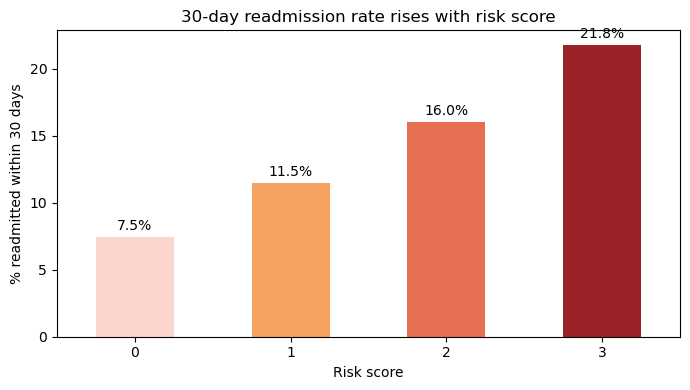

In [14]:
import matplotlib.pyplot as plt
import os

os.makedirs("images_readmit", exist_ok=True)   # separate folder name so it doesn't mix with your fraud project's images

df_score = q("SELECT risk_score, readmit_30 FROM RiskScore")
rate = df_score.groupby("risk_score")["readmit_30"].mean() * 100

ax = rate.plot(kind="bar", color=["#fcd5ce","#f4a261","#e76f51","#9b2226"], figsize=(7,4), rot=0)
ax.set_title("30-day readmission rate rises with risk score")
ax.set_xlabel("Risk score")
ax.set_ylabel("% readmitted within 30 days")
for i, v in enumerate(rate):
    ax.text(i, v+0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.savefig("images_readmit/readmit_rate_by_score.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
shortlist = q("""
SELECT encounter_id, patient_nbr, risk_score, number_inpatient, number_emergency, number_diagnoses,
       TRIM(CASE WHEN prior_admit_pt=1 THEN 'Prior inpatient stay. ' ELSE '' END ||
            CASE WHEN prior_er_pt=1 THEN 'Prior ER visit. ' ELSE '' END ||
            CASE WHEN high_diag_pt=1 THEN 'High diagnosis count.' ELSE '' END) AS why_flagged
FROM RiskScore WHERE risk_score >= 2
ORDER BY risk_score DESC
""")

os.makedirs("outputs_readmit", exist_ok=True)
shortlist.to_csv("outputs_readmit/high_risk_encounters.csv", index=False)
print(shortlist.shape)

(23536, 7)


In [16]:
import os
print(os.getcwd())

C:\Users\TEWELDE
